<h2><center>Assignment 3</center></h2>
<h3><center>Programming for Data Science 2026</center></h3>
<b><center>Deadline: 14:00, March 12, 2026</center></b>

- The exercise will be marked as **passed** if you get **at least 10/16** points.

- Exercises must be handed in via **ILIAS** (Homework assignments). Submit your work as a **compressed (.zip)** file containing **one** `.py` **or** `.ipynb` file with **all exercises**.

- The name of **both** the `.zip` file and the `.py`/`.ipynb` file must be the *SurnameName* of the **two group members**, separated by an underscore.  
  Example: Tim Tabellen and Lara Lambda → `TabellenTim_LambdaLara.zip`  
  (The `.py`/`.ipynb` file must have the same name.)

- Use **comments** to explain your code and demonstrate that you understand the solutions and can discuss them.

- You are not expected to collaborate outside your group. Submitting other groups’ code as your own will result in **0 points**.

- For general questions about the lecture content, assignments, or the exam, please use the **ILIAS forum**.

- For individual questions about lecture content and the exam, contact: *roland.widmer@students.unibe.ch*  

- For individual questions about the exercises or grading, contact: *julien.brunner@students.unibe.ch* or *aline.steiner@students.unibe.ch*

#### Exercise 1: Numpy array from scratch *(1 point)*

Create a numpy array named `numbers` from the list `[1, 2, 4, 5]`.

In [ ]:
# TODO

numbers are of type: <class 'numpy.ndarray'>. [1 2 3 4]


Determine datatype and shape of `numbers`.

In [ ]:
# TODO

#### Exercise 2: Numpy speed *(2 points)*

We want to calculate the sum of 100 million (!) squared random numbers between 0 and 1. Below a slow implementation:

In [ ]:
import numpy as np

random_numbers = np.random.random(100000000)

result = 0
for i in random_numbers:
    result += i ** 2

print(result)

Make it faster, by using Numpy's capabilities.

In [ ]:
# TODO

#### Exercise 3: Numpy views *(2 points)*

Data sets often contain outliers. In this example, we set a threshold of 10 and replace elements larger than 10 with `np.nan`.

In [4]:
import numpy as np

raw_data = np.array([1.2, 2.3, 20.1, 1.1, 2.2])

cleaned_data = raw_data.copy()
cleaned_data[cleaned_data > 10] = np.nan # mark values greater than 10 as missing

print(raw_data)
print(cleaned_data)

[ 1.2  2.3 20.1  1.1  2.2]
[1.2 2.3 nan 1.1 2.2]


Comparing `raw_data` and `clean_data`, we see that the outlier was also removed from `raw_data`.

Explain why this is happening and how we prevent it.

**Your answer:** Similar as for normal python objects this code does not create a new np.array. It just creates a second variable pointing to the same memory. So if one is modified the other changes too. Yet we can prevent it by adding .copy() to make sure a new memory location is allocated for the variable cleaned_data (see code snipped above).

#### Exercise 4: Image *(6 points)*

An image consists of $n_{height} * n_{width}$ pixels which all have a color. This color can be represented in three values: red, green, and blue (RGB). The color values are bounded between 0 and 255, while higher values means a brighter color.

Examples: red (255, 0, 0), black (0, 0, 0), white (255, 255, 255)


Run the this cell to load the image and define some helper functions.

(1536, 1024, 3)


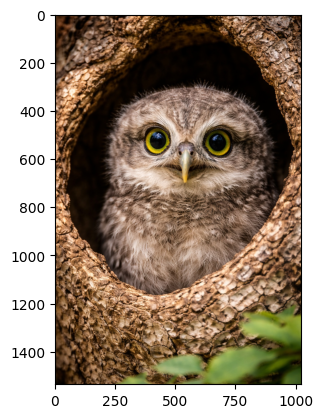

In [73]:
import matplotlib.pyplot as plt
import numpy as np

def load_image(path):
    # you don't need to understand this code (yet...)
    image_data = plt.imread(path)
    image_data = np.array(image_data)
    return image_data

def plot_image(image_data):
    # you don't need to understand this code (yet...)
    plt.imshow(image_data)
    plt.show()



image_data = load_image("../data/images/owl.jpg")

print(image_data.shape)

plot_image(image_data)

Get the number of bytes occupied in memory by a single element of the numpy array. Explain the result.

In [76]:
# TODO
image_data.itemsize
image_data.dtype

dtype('uint8')

**Your answer**: TODO

Next, we look at a single pixel. Print the the RGB-values at x=538, y=686.

Hint: The first dimension is related to the Y axis, and the second dimension to the X axis.

In [79]:
# TODO
image_data[686, 538]

array([242, 188,  64], dtype=uint8)

Downsample the image by only considering every 5th pixel (using numpy slicing). Plot the result with the function `plot_image`.

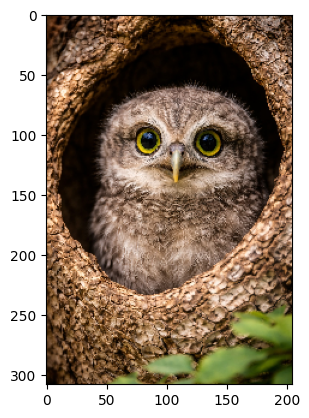

189420
4718592


In [88]:
# TODO
down_sample = image_data[::5,::5]
plot_image(down_sample)
print(down_sample.size)
print(image_data.size)

To provide privacy to the owl, create first a copy of the numpy array and assign it to `image_data_anonymized`. Then, create a black bar starting at pixel x=330, y=500 with a black of height 79 px and width 423 px. Plot the result with the function `plot_image`.

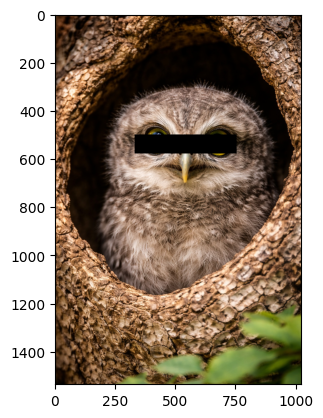

In [89]:
# TODO
image_data_anonymized = image_data.copy()
image_data_anonymized[500:579, 330:753] = 0
plot_image(image_data_anonymized)


Flip the original image horizontally (left to right) and plot the result.

Hint: Have a look at the [documentation](https://numpy.org/doc/stable/reference/routines.array-manipulation.html) to find the appropriate function.

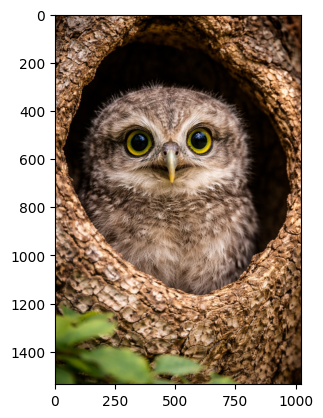

In [91]:
# TODO
flipped = np.fliplr(image_data)
plot_image(flipped)

Convert the image to grayscale using the luminosity method: $\text{gray} = 0.2989 \times R + 0.5870 \times G + 0.1140 \times B$. Plot the result.

Hint: Greyscale has to be converted back to RGB.

[[53.8149 54.8148 54.8857 ... 56.8668 41.2535 33.2974]
 [52.815  53.8149 54.8857 ... 41.0964 23.7822 15.4132]
 [52.114  54.1138 55.1137 ... 27.9667 16.8969 13.6414]
 ...
 [ 3.8533  2.9674  2.9674 ... 70.907  71.9069 72.9068]
 [ 4.0813  4.0813  3.0814 ... 71.9069 71.9069 72.9068]
 [ 5.0812  4.0813  3.0814 ... 72.9068 72.9068 71.9069]]


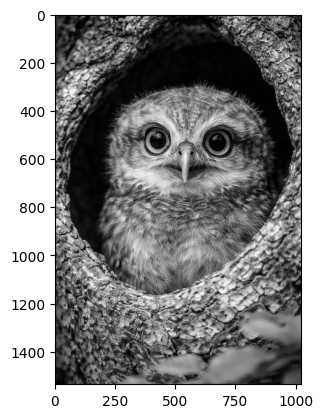

In [105]:
# TODO
gray = 0.2989 * image_data[:,:,0] + 0.5870 * image_data[:,:,1] + 0.1140 * image_data[:,:,2]
print(gray)
rgb = np.stack([gray, gray, gray], axis = 2).astype(np.uint8)
plot_image(rgb)

#### Exercise 5: Timeseries *(5 points)*

In this exercise, we work with daily water temperature data from the Aare river in Bern. 

Source: [Hydrology Division, Federal Office for the Environment FOEN (2026)](https://www.hydrodaten.admin.ch/en/seen-und-fluesse/messstationen-temperatur).

First, we define some helper functions:

- `get_daily_temperature_data`: returns the daily temperature data for a given year
- `get_monthly_temperature_data`: returns the monthly average temperature for all available years
- `plot_temperature`: plots the the temperature for a given numpy array

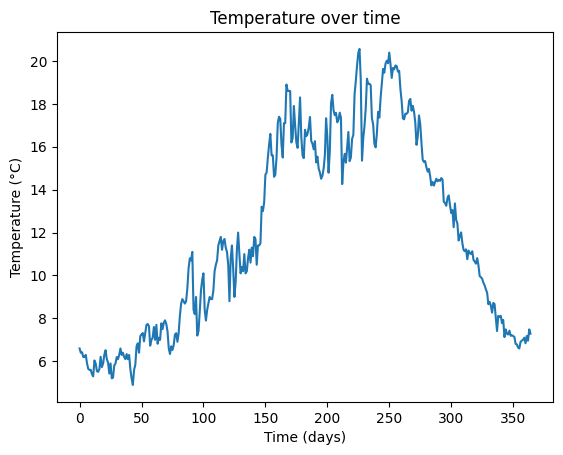

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_daily_temperature_data(year: int):
    # you don't need to understand this code (yet...)
    temperature_df = pd.read_csv(f"../data/csv/aare_temperature.csv", parse_dates=["timestamp"])

    temperature_df = temperature_df[temperature_df["timestamp"].dt.year == year]
    
    return temperature_df["value"].to_numpy()

def get_monthly_temperature_data():
    # you don't need to understand this code (yet...)
    temperature_df = pd.read_csv(
        "../data/csv/aare_temperature.csv",
        parse_dates=["timestamp"]
    )

    temperature_df["year"] = temperature_df["timestamp"].dt.year
    temperature_df["month"] = temperature_df["timestamp"].dt.month

    grouped = (
        temperature_df
        .groupby(["year", "month"])["value"]
        .mean()
        .unstack("month")
        .sort_index()
    )

    return grouped.to_numpy()


def plot_temperature(temperature_data, time_unit="days"):
    # you don't need to understand this code (yet...)
    plt.plot(temperature_data)
    plt.xlabel(f"Time ({time_unit})")
    plt.ylabel("Temperature (°C)")
    plt.title(f"Temperature over time")
    plt.show()


temperature_2021 = get_daily_temperature_data(2021)
plot_temperature(temperature_2021)


Get the temperatures using `get_daily_temperature_data` from 2024 and 2025 and store it in a single 1d-numpy array. Plot the result using `plot_temperature`.

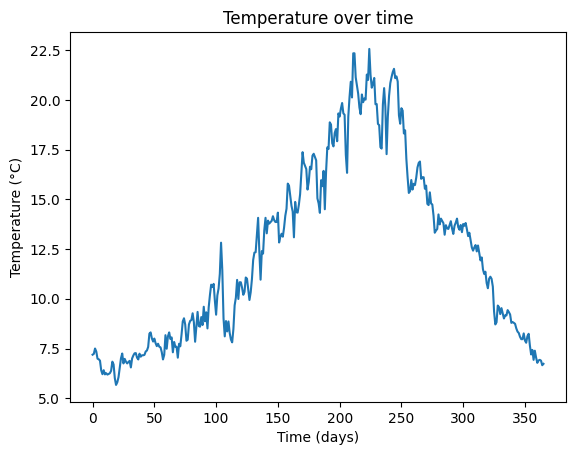

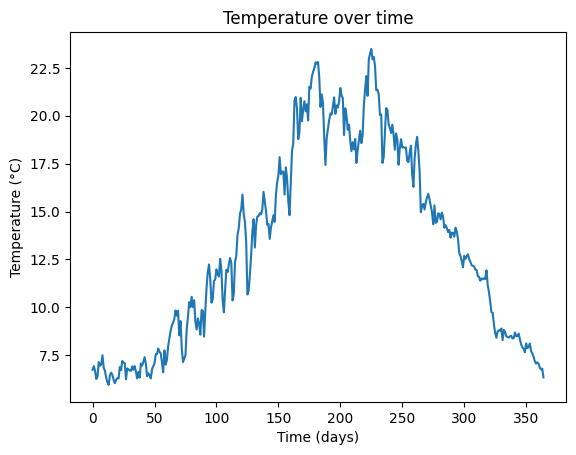

2024 type: <class 'numpy.ndarray'>, length: 366
2025 type: <class 'numpy.ndarray'>, length: 365


In [ ]:
# TODO
#getting the daily temperatures as np.arrays
daily_temp_2024 = np.array(get_daily_temperature_data(2024))
daily_temp_2025 = np.array(get_daily_temperature_data(2025))

#ploting the np.arrays of the daily temps
plot_temperature(daily_temp_2024)
plot_temperature(daily_temp_2025)

#checking types of the two objects
print(f'2024 type: {type(daily_temp_2024)}, length: {len(daily_temp_2024)}') # 366 datapoints, since it is a leap year
print(f'2025 type: {type(daily_temp_2025)}, length: {len(daily_temp_2025)}') # 365 days, normal year

Get the minimum, maximum and mean temperature across the two years.

In [22]:
# TODO

arr_2024_2025 = np.concatenate([daily_temp_2024,daily_temp_2025])
max_2024_2025 = np.max(arr_2024_2025 )
min_2024_2025 = np.min(arr_2024_2025 )
mean_2024_2025 = np.sum(arr_2024_2025 )/len(arr_2024_2025 )

print(f'max temp was: {max_2024_2025}, min temp was: {min_2024_2025}, and mean was: {mean_2024_2025}.')

max temp was: 23.49, min temp was: 5.67, and mean was: 12.771573187414502.


Implement code that calculates the days, on which the minimum and the maximum temperature was reached. You can give the result in days passed since the January 1, 2024.

Example: Highest temperature was reached on the January 3, 2024. Answer: 2

Hint: Have a look at the [documentation](https://numpy.org/doc/2.3/reference/routines.sort.html#searching).

In [26]:
# TODO
# getting the poisitions of min and max which is equal to the days passed since jan 1 2024
index_max = np.argmax(arr_2024_2025)
index_min = np.argmin(arr_2024_2025)

#printing the indices
print(f'day on which max temperature was reached: {index_max}, day on which the minimum was reached: {index_min}.')

# checking for correct reults
print(f'max temp was: {arr_2024_2025[index_max]}, min temp was {arr_2024_2025[index_min]}')

day on which max temperature was reached: 591, day on which the minimum was reached: 19.
max temp was: 23.49, min temp was 5.67


Use `get_monthly_temperature_data` to get monthly average temperatures from years 2004 up to 2025. Calculate the mean temperature per month and plot it with `plot_temperatures` (with `time_unit="months"`).

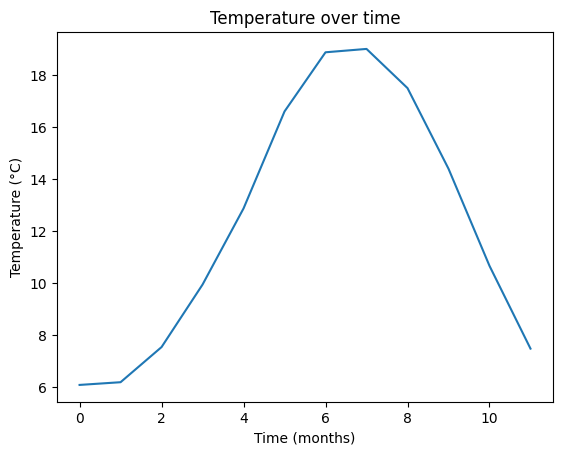

In [57]:
# TODO
#loading monthly temp
month_temps = get_monthly_temperature_data()

#calculating mean monthly temperatures
mean_month_temps = [sum(month_temps[:,i])/len(month_temps[:,i]) for i in range(month_temps.shape[1])]

#plotting monthly temps
plot_temperature(mean_month_temps, time_unit = "months")

Calculate the yearly average per year. From this, the year with the maximum average water temperature.

In [72]:
# TODO
#loading monthly temp
month_temps = get_monthly_temperature_data()

#calculating mean monthly temperatures
mean_year_temps = [sum(month_temps[i,:])/len(month_temps[i,:]) for i in range(month_temps.shape[0])]

#getting index of year with max temp
index_max_temp = np.argmax(mean_year_temps)

#since indexing starts at 0 (corresponds to year 2004) the index should correspond to 2004 + index_max_temp
year_max_temp = 2004 + index_max_temp
print(f'Highest average temperature was measured in the year {year_max_temp}.')


Highest average temperature was measured in the year 2022.
